**Project Title**:This project analyzes a retail store sales performance data to answer key business questions around revenue trends across regions, customer segments, products and effect of discounts on revenue

**Problem:** The marketing team has been applying discounts (0–30%) broadly, but leadership suspects they're leaving money on the table by giving discounts to customers who would have bought anyway.

**Business Questions:**

1.   Are discounts actually driving incremental revenue, or are we giving away margin to customers who would have bought anyway?
2.  What are the top performing product categories, regions and channels?


In [ ]:
import pandas as pd
import numpy as np
Sales=pd.read_csv('/content/retail_sales_dataset.csv')
Sales.head(5)

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central


In [ ]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      120000 non-null  object 
 1   transaction_date    120000 non-null  object 
 2   customer_id         120000 non-null  object 
 3   customer_gender     120000 non-null  object 
 4   customer_age_group  120000 non-null  object 
 5   customer_segment    120000 non-null  object 
 6   product_id          120000 non-null  object 
 7   product_name        120000 non-null  object 
 8   category            120000 non-null  object 
 9   brand               120000 non-null  object 
 10  quantity            120000 non-null  int64  
 11  unit_price          120000 non-null  float64
 12  discount_pct        120000 non-null  int64  
 13  sales_amount        120000 non-null  float64
 14  payment_method      120000 non-null  object 
 15  sales_channel       120000 non-nul

In [ ]:
#What are the unique values in each column
for columns in Sales.columns:
  print(columns)
  print(Sales[columns].unique())

transaction_id
['T0000001' 'T0000002' 'T0000003' ... 'T0119998' 'T0119999' 'T0120000']
transaction_date
['2024-04-24' '2025-07-12' '2025-06-01' '2025-08-26' '2024-12-10'
 '2024-02-14' '2025-10-05' '2024-10-23' '2025-01-14' '2024-09-07'
 '2024-02-27' '2025-08-03' '2024-09-28' '2025-01-05' '2025-10-04'
 '2025-06-25' '2024-10-27' '2024-04-18' '2025-06-27' '2024-11-10'
 '2024-03-11' '2025-06-24' '2025-06-13' '2025-07-21' '2024-03-10'
 '2025-07-06' '2024-04-06' '2024-02-25' '2024-04-21' '2025-04-18'
 '2024-01-16' '2025-02-14' '2025-03-09' '2024-02-29' '2025-05-03'
 '2025-09-01' '2025-08-31' '2024-09-24' '2025-10-22' '2024-04-12'
 '2025-10-31' '2024-04-19' '2024-12-17' '2025-03-28' '2024-02-06'
 '2025-01-08' '2025-02-20' '2024-07-02' '2024-02-09' '2024-01-25'
 '2025-10-18' '2025-08-17' '2025-09-12' '2025-06-16' '2024-11-17'
 '2024-10-29' '2025-08-05' '2025-08-16' '2025-04-29' '2024-04-05'
 '2025-12-14' '2024-05-04' '2025-07-15' '2025-06-17' '2024-10-05'
 '2025-12-11' '2025-04-22' '2025-08-12

In [ ]:
# Changing data type of transaction date column from object to date type
Sales['transaction_date']=pd.to_datetime(Sales['transaction_date'])
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      120000 non-null  object        
 1   transaction_date    120000 non-null  datetime64[ns]
 2   customer_id         120000 non-null  object        
 3   customer_gender     120000 non-null  object        
 4   customer_age_group  120000 non-null  object        
 5   customer_segment    120000 non-null  object        
 6   product_id          120000 non-null  object        
 7   product_name        120000 non-null  object        
 8   category            120000 non-null  object        
 9   brand               120000 non-null  object        
 10  quantity            120000 non-null  int64         
 11  unit_price          120000 non-null  float64       
 12  discount_pct        120000 non-null  int64         
 13  sales_amount        120000 no

In [ ]:
Sales['transaction_month'] = Sales['transaction_date'].dt.to_period('M')
Sales.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,transaction_month
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,2024-04
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,2025-07
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,2025-06
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,2025-08
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,2024-12


In [ ]:
Sales['transaction_quarter'] = Sales['transaction_date'].dt.to_period('Q')
Sales.head()

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,transaction_month,transaction_quarter
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,2024-04,2024Q2
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,2025-07,2025Q3
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,2025-06,2025Q2
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,2025-08,2025Q3
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,2024-12,2024Q4


# **EXPLORATORY DATA ANALYSIS**

In [ ]:
#What is the total revenue generated from 120k transactions
total_sales=Sales['sales_amount'].sum()
print('The total revenue generated is : $', round(total_sales,2))

The total revenue generated is : $ 45357054.45


The total revenue generated from 120k transactions is $ 45,357,054

In [ ]:
#What is the total revenue generated in 2024 and 2025
total_sales_2024 = Sales[Sales['transaction_date'].dt.year == 2024]['sales_amount'].sum()
print('Total revenue generated in 2024: $', round(total_sales_2024, 2))

Total revenue generated in 2024: $ 22786404.01


A total revenue of $ 22,786,404 was generated in 2024

In [ ]:
#What is the total revenue generated in 2025
total_sales_2025 = Sales[Sales['transaction_date'].dt.year == 2025]['sales_amount'].sum()
print('Total revenue generated in 2025: $', round(total_sales_2025, 2))

Total revenue generated in 2025: $ 22570650.44


A total revenue of  $ 22,570,650 was generated in 2025

In [ ]:
# What is the yearly percentage drop in Sales
pct_sales_drop= (total_sales_2025-total_sales_2024)/total_sales_2024
pct_sales_drop=pct_sales_drop*100
print('The percentage sales drop from 2024 to 2025 is :', round(pct_sales_drop,2), '%')

The percentage sales drop from 2024 to 2025 is : -0.95 %


Total revenue hit $45.4M across 120K transactions, but 2025 came in 0.95% below 2024 representing a slight decline despite similar transaction volumes

In [ ]:
#What is the average order value for all 120k transactions
avg_order_value=total_sales/Sales['transaction_id'].nunique()
print('The average order value is : $', round(avg_order_value))

The average order value is : $ 378


In [ ]:
#What is the number of orders, qty sold, revenue and avg order value per region
regional_summary=Sales.groupby('region').agg(Orders=('transaction_id','nunique'),qty_sold=('quantity','sum'),revenue=('sales_amount','sum'),avg_order_value=('sales_amount','mean')).reset_index()
regional_summary = regional_summary.sort_values(by='revenue',ascending=False)
regional_summary.set_index('region', inplace=True)
regional_summary

,Orders,qty_sold,revenue,avg_order_value
region,,,,
Central,24244,40617,9237924.11,381.039602
West,23950,39852,9106911.70,380.246835
North,24075,39935,9049438.11,375.885280
South,24066,39852,8991262.89,373.608530
East,23665,39293,8971517.64,379.104908


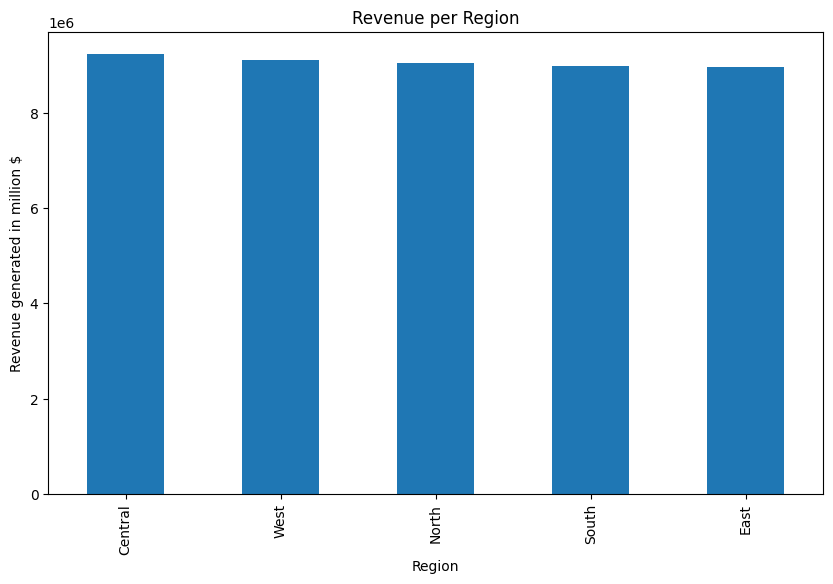

<Figure size 640x480 with 0 Axes>

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
regional_summary['revenue'].plot(kind='bar')
plt.title('Revenue per Region')
plt.xlabel('Region')
plt.ylabel('Revenue generated in million $')
plt.show()
plt.savefig('Sales Revenue by regions.png')

Central and West appear to be the best performing regions in terms of revenue generated with 9.2M and 9.1M respectively due to high numbers for average order value and quantity sold. Although regional differences are minimal. The spread is only ~3%, suggesting either uniform market performance or a lack of targeted regional strategy

In [ ]:
#What is the number of orders, ,qty sold and revenue and avg order value per customer segment
customer_summary=Sales.groupby('customer_segment').agg(Orders=('transaction_id','nunique'),revenue=('sales_amount','sum'),avg_order_value=('sales_amount','mean')).reset_index()
customer_summary.sort_values(by='customer_segment',ascending=False)
customer_summary.set_index('customer_segment', inplace=True)
customer_summary

,Orders,revenue,avg_order_value
customer_segment,,,
Loyal,30014,11393721.23,379.613555
New,30020,11331906.60,377.478568
Returning,29851,11311255.31,378.923832
VIP,30115,11320171.31,375.898101


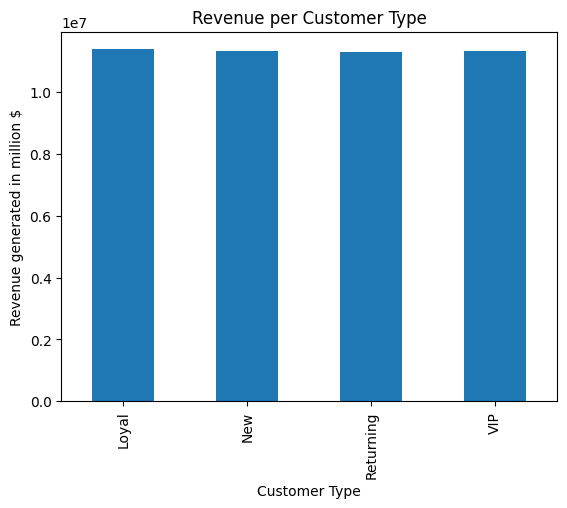

<Figure size 640x480 with 0 Axes>

In [63]:
customer_summary['revenue'].plot(kind='bar')
plt.title('Revenue per Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Revenue generated in million $')
plt.show()
plt.savefig('Sales Revenue by various customer segments.png')

In [68]:
prd_cat_summary=Sales.groupby('category').agg(Orders=('transaction_id','nunique'),qty_sold=('quantity','sum'),revenue=('sales_amount','sum'),avg_order_value=('sales_amount','mean')).reset_index()
prd_cat_summary = prd_cat_summary.sort_values(by='revenue',ascending=False)
prd_cat_summary.set_index('category', inplace=True)
display(prd_cat_summary)

,Orders,qty_sold,revenue,avg_order_value
category,,,,
Beauty,15073,25171,6355718.23,421.662458
Books,14556,24042,6005237.69,412.560984
Sports,15218,25183,5863370.76,385.291810
Electronics,15008,24866,5859686.69,390.437546
Home,14933,24916,5655562.80,378.729177
Toys,15022,25039,5557562.19,369.961536
Groceries,15034,25109,5431536.64,361.283533
Clothing,15156,25223,4628379.45,305.382650


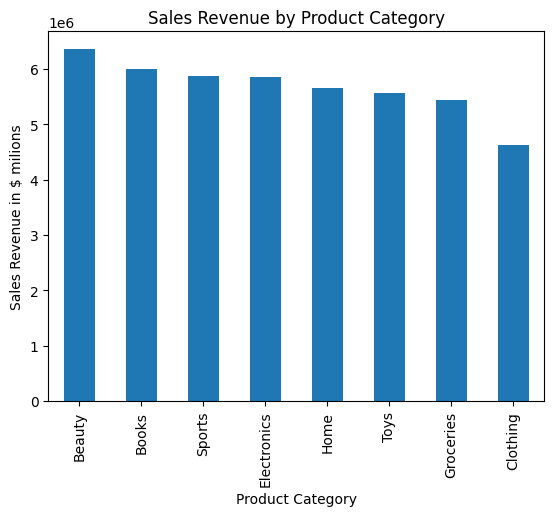

<Figure size 640x480 with 0 Axes>

In [64]:
# What are the highest revenue generating product
prd_cat_sales=Sales.groupby('category')['sales_amount'].sum().sort_values(ascending=False)
prd_cat_sales.plot(kind='bar')
plt.title('Sales Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales Revenue in $ milions')
plt.show()
plt.savefig('Sales Revenue by different product category.png')

Beauty and Books are the revenue leaders, $6.4M and $ 6.0M respectively , driven by higher average order values ($422 and $413). Clothing, despite having the most units sold (25,223), generates the least revenue ($4.6M) because its average order is just $ 305, a clear sign of heavy discounting or low price points eroding value.

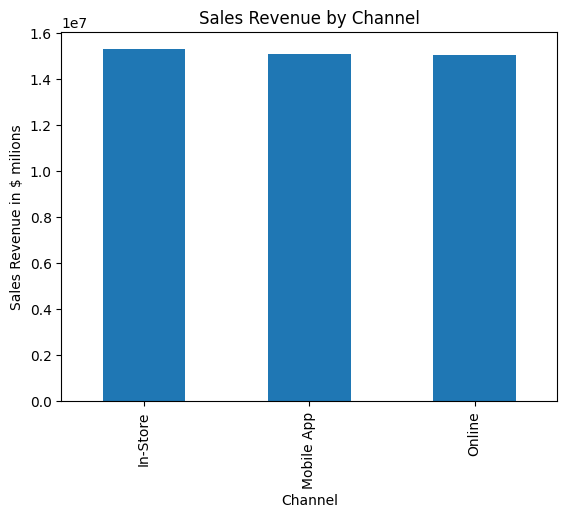

<Figure size 640x480 with 0 Axes>

In [65]:
# What sales channel generates the most revenue?
channel_sales=Sales.groupby('sales_channel')['sales_amount'].sum().sort_values(ascending=False)
channel_sales.plot(kind='bar')
plt.title('Sales Revenue by Channel')
plt.xlabel('Channel')
plt.ylabel('Sales Revenue in $ milions')
plt.show()
plt.savefig('Sales Revenue by Channel.png')

Channels are nearly perfectly split — In-Store, Mobile App, and Online each contribute roughly a third of revenue. This even distribution is unusual and worth investigating: it could mean the company is channel-agnostic (good), or that no channel is being deliberately optimized (a missed opportunity)

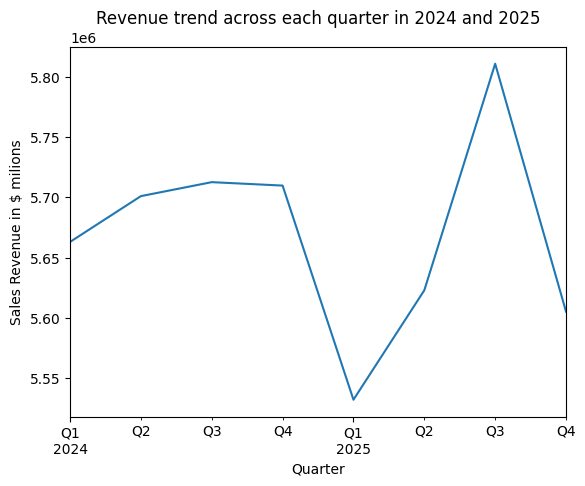

<Figure size 640x480 with 0 Axes>

In [66]:
# How did revenue generated in each quarter change from 2024 to 2025
Sales.groupby('transaction_quarter')['sales_amount'].sum().plot(kind='line')
plt.title('Revenue trend across each quarter in 2024 and 2025')
plt.xlabel('Quarter')
plt.ylabel('Sales Revenue in $ milions')
plt.show()
plt.savefig('Revenue trend across each quarter in 2024 and 2025.png')

The quarterly trend shows no strong seasonality or growth trajectory in either year, which is a red flag for a retail business that should be growing.

,Discount Percentage,Average Order Value ($)
0,0,399.465509
1,5,381.917852
2,10,360.452565
3,15,339.633701
4,20,323.275968
5,25,299.897565
6,30,274.179770


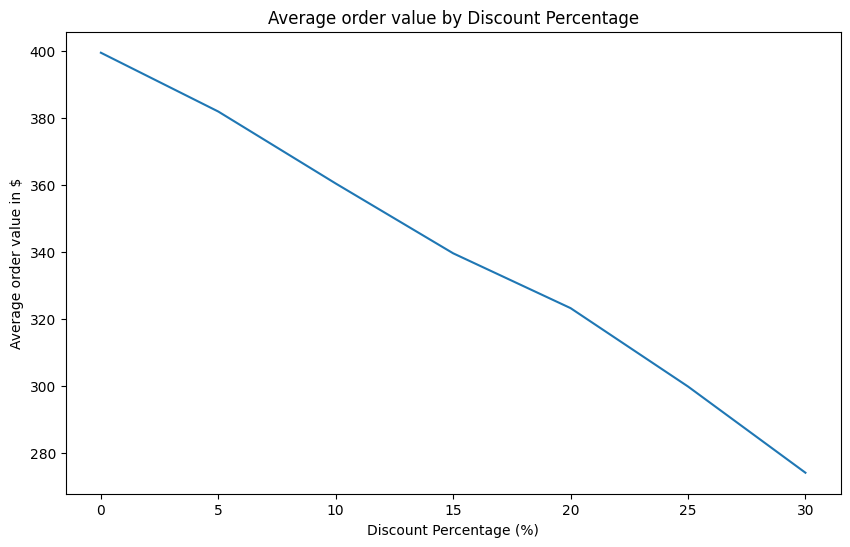

<Figure size 640x480 with 0 Axes>

In [67]:
# How are the discounts contributing to average order value and revenue
aov_by_discount = Sales.groupby('discount_pct')['sales_amount'].mean()
aov_df = aov_by_discount.reset_index()
aov_df.columns = ['Discount Percentage', 'Average Order Value ($)']
display(aov_df)

# Plotting the data
aov_by_discount.plot(kind='line', figsize=(10,6))
plt.title('Average order value by Discount Percentage')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Average order value in $')
plt.show()
plt.savefig('Average order value by percentage discount offered.png')

AOV drops from $399 → $274 as discount increases. Each 5% more discount costs ~$20 in order value.

In [ ]:
order_qty_discount=Sales.groupby('discount_pct')['quantity'].mean()
order_qty_discount=round(order_qty_discount,2)
order_qty_discount=order_qty_discount.reset_index()
order_qty_discount.columns=['Discount Percentage','Average Order Quantity']
display(order_qty_discount)

,Discount Percentage,Average Order Quantity
0,0,1.66
1,5,1.64
2,10,1.66
3,15,1.67
4,20,1.67
5,25,1.66
6,30,1.66


Average quantity is 1.66 units at every discount level indicating zero volume lift. The discounts don't drive customers to buy more.

In [ ]:
# How much did we lose by giving discounts
Sales['full_sales']= Sales['quantity']*Sales['unit_price']
actual_sales=Sales['full_sales'].sum()
amount_lost= actual_sales - total_sales
print('The total revenue that could be made without discount was $', round(actual_sales))
print('A total of $', round(amount_lost), 'was lost due to discounts')

The total revenue that could be made without discount was $ 47996218
A total of $ 2639164 was lost due to discounts


As a result, $2.64M is given away in discounts out of $48M full-price value

In [ ]:
Sales.head(5)

,transaction_id,transaction_date,customer_id,customer_gender,customer_age_group,customer_segment,product_id,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region,transaction_month,transaction_quarter,full_sales
0,T0000001,2024-04-24,C000820,Other,35-44,Returning,P1082,Dumbbells,Sports,Brand 1,2,313.53,20,501.65,Debit Card,Online,North,2024-04,2024Q2,627.06
1,T0000002,2025-07-12,C002849,Other,45-54,New,P1087,Running Shoes,Sports,Brand 3,1,366.16,0,366.16,Credit Card,Online,South,2025-07,2025Q3,366.16
2,T0000003,2025-06-01,C019727,Male,55+,Returning,P1030,Sneakers,Clothing,Brand 3,1,27.99,0,27.99,Gift Card,In-Store,South,2025-06,2025Q2,27.99
3,T0000004,2025-08-26,C009116,Male,25-34,VIP,P1058,Sunscreen,Beauty,Brand 1,2,102.01,15,173.42,Cash,In-Store,South,2025-08,2025Q3,204.02
4,T0000005,2024-12-10,C003350,Male,45-54,New,P1028,Sneakers,Clothing,Brand 1,1,259.55,0,259.55,Cash,In-Store,Central,2024-12,2024Q4,259.55


In [60]:
#What is the average percentage discount and purchase frequency across each customer segment
discount_summary=Sales.groupby('customer_segment').agg(total_transactions=('transaction_id', 'count'),
    unique_customers=('customer_id', 'nunique'),avg_discount=('discount_pct','mean'),avg_order_value=('sales_amount','mean')).reset_index()
discount_summary['purchase frequency']=discount_summary['total_transactions']/discount_summary['unique_customers']
discount_summary.set_index('customer_segment', inplace=True)
discount_summary

,total_transactions,unique_customers,avg_discount,avg_order_value,purchase frequency
customer_segment,,,,,
Loyal,30014,17336,5.518758,379.613555,1.731311
New,30020,17524,5.455197,377.478568,1.713079
Returning,29851,17435,5.553750,378.923832,1.712131
VIP,30115,17535,5.458741,375.898101,1.717422


The segments are functionally identical. Every metric tells the same story: VIP, Loyal, Returning, and New customers have the same AOV ($376–$380) and the same average discount (5.5%). The company doesn't have a segmentation strategy, it has segmentation labels. A real VIP segment should show higher purchase frequency, higher AOV, and lower discount dependency than new customers

## **ANALYSIS SUMMARY**

1. Across 120,000 transactions and $45.4M in revenue, the company gave away $2.64M in discounts that produced zero incremental volume, applied identical treatment to all customer segments, and saw revenue decline 0.95% year-over-year.
2.   Are discounts actually driving incremental revenue? The data says no, quantity didn't increase, and our most loyal customers received the same discounts as new ones
3.   The purchase frequency analysis revealed that the average customer buys only 1.72 times over two years. This is the single biggest drag on revenue. AOV is a reasonable $378, so the problem isn't how much customers spend per visit, it's that they don't visit again.
4. Beauty and Books are the revenue leaders in terms of product category
5. Central and West appear to be the best performing regions. However, there is no targeted regional strategy

**Recommendation**

 1.  The company needs to build a genuine tiered experience for its customers. VIPs should get exclusive perks instead of discounts. New customers should get onboarding incentives. Loyal customers should get early access to new products.
 2. The company needs a post-purchase re-engagement program: follow-up emails within 7 days of first purchase, a "second purchase" incentive targeted specifically at one-time buyers



